# Chapter 63 — Step Functions

> **Prerequisites:** ch062 (Piecewise Functions)
>
> **You will learn:**
> - Define step functions and Heaviside function
> - Understand floor, ceiling, and rounding as step functions
> - Connect step functions to digital signals and threshold logic
> - Implement step-based quantization
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **step function** (or staircase function) is a piecewise function that is constant on each interval and jumps at a finite set of points.

The most important step function is the **Heaviside function**:
H(x) = { 0 if x < 0; 1 if x ≥ 0 }

Any piecewise constant function can be built from Heaviside shifts:
f(x) = Σ (cₖ - cₖ₋₁) · H(x - aₖ)

Related functions:
- **Floor** ⌊x⌋: largest integer ≤ x
- **Ceiling** ⌈x⌉: smallest integer ≥ x  
- **Round**: nearest integer
- **Sign**: -1, 0, or 1

**Applications:**
- Quantization in neural networks: float → int representation
- Digital signal processing: sampling continuous signals
- Threshold classifiers: output class 0 or 1 based on a cutoff

---

## 2. Intuition & Mental Models

**Physical analogy:** Light switches. Each switch is at a fixed position; when a threshold is crossed, the state changes. A circuit with many switches is a step function of voltage.

**Computational analogy:** The comparison operator `x > 0` returns 0 or 1 — a step function. Bitwise operations, integer division, and modulo all involve step functions internally.

---

## 3. Visualization

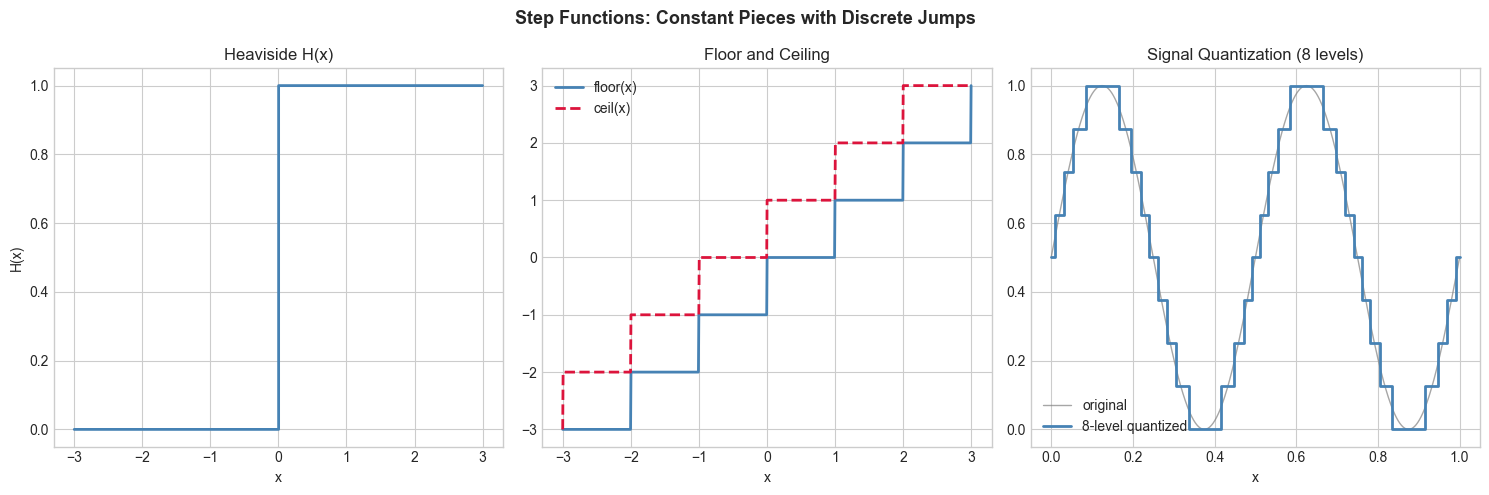

In [1]:
# --- Visualization: Step functions ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-3, 3, 1000)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Heaviside
h = np.where(x >= 0, 1.0, 0.0)
axes[0].step(x, h, color='steelblue', linewidth=2, where='post')
axes[0].set_title('Heaviside H(x)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('H(x)')

# Floor and ceiling
axes[1].plot(x, np.floor(x), color='steelblue', linewidth=2, label='floor(x)')
axes[1].plot(x, np.ceil(x), color='crimson', linewidth=2, linestyle='--', label='ceil(x)')
axes[1].set_title('Floor and Ceiling')
axes[1].set_xlabel('x'); axes[1].legend()

# Quantization
N_LEVELS = 8  # <-- try changing
x_cont = np.linspace(0, 1, 500)
y_sine = 0.5 * np.sin(4*np.pi*x_cont) + 0.5
y_quant = np.round(y_sine * N_LEVELS) / N_LEVELS
axes[2].plot(x_cont, y_sine, color='gray', linewidth=1, label='original', alpha=0.7)
axes[2].step(x_cont, y_quant, color='steelblue', linewidth=2, label=f'{N_LEVELS}-level quantized', where='post')
axes[2].set_title(f'Signal Quantization ({N_LEVELS} levels)')
axes[2].set_xlabel('x'); axes[2].legend()

plt.suptitle('Step Functions: Constant Pieces with Discrete Jumps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Heaviside function:** H(x) = 0 for x<0, 1 for x≥0

**Rectangular pulse:** Π(x) = H(x) - H(x-1) — selects a window

**Floor function:** ⌊x⌋ = max{n ∈ ℤ : n ≤ x}

**Quantization:** q(x) = ⌊x · L⌋ / L maps continuous values to L discrete levels

In [2]:
# --- Implementation: Step function toolkit ---
import numpy as np

def heaviside(x, at_zero=1.0):
    """Heaviside function with configurable value at x=0."""
    return np.where(x > 0, 1.0, np.where(x == 0, float(at_zero), 0.0))

def pulse(x, a, b):
    """Rectangular pulse: 1 on [a, b), 0 elsewhere."""
    return (heaviside(x - a) - heaviside(x - b)).astype(float)

def quantize(x, n_levels):
    """Uniform quantization to n_levels discrete values in [0, 1]."""
    x = np.clip(x, 0, 1)
    step = 1.0 / (n_levels - 1)
    return np.round(x / step) * step

# Test quantization error
np.random.seed(0)
x_data = np.random.uniform(0, 1, 1000)
for L in [4, 8, 16, 256]:
    q = quantize(x_data, L)
    mse = np.mean((x_data - q)**2)
    print(f"  {L:3d} levels: MSE = {mse:.6f}")

    4 levels: MSE = 0.008854
    8 levels: MSE = 0.001665
   16 levels: MSE = 0.000374
  256 levels: MSE = 0.000001


---

## 6. Experiments

**Experiment 1:** Build a step function approximation to sin(x): at 8 equally spaced x values, sample sin(x) and hold the value constant until the next sample. Compare to the true sin(x) — this is zero-order hold interpolation.

**Experiment 2:** Quantize an image (numpy 2D array) to 2, 4, 8, 256 levels. At which quantization do images become unrecognizable?

---

## 7. Exercises

**Easy 1.** What is ⌊3.7⌋? ⌈-2.3⌉? ⌊-2.7⌋? Verify with `np.floor` and `np.ceil`.

**Easy 2.** Use the Heaviside function to implement `relu(x) = max(0, x)` as `x * H(x)`.

**Medium 1.** Write a threshold classifier: given array x, return 1 where x > threshold, 0 otherwise. Apply to a noisy sine wave with threshold = 0.

**Medium 2.** Implement `sample_and_hold(f, n_samples, x_range)`: sample f at n_samples uniformly spaced points and return a step function that holds each value until the next sample.

**Hard.** Prove algebraically (or verify numerically) that ⌊x⌋ + ⌊y⌋ ≤ ⌊x+y⌋ ≤ ⌊x⌋ + ⌊y⌋ + 1 for all real x, y. Then show this implies that the floor function is sub-additive.

---

## 9. Chapter Summary & Connections

- Step functions are piecewise constant; jumps occur at discrete points
- Heaviside, floor, ceiling, sign, round are the standard step functions
- Quantization maps continuous signals to discrete levels — step functions applied to ranges
- The derivative of a step function is a spike (Dirac delta) — important in signal processing

**Forward connections:**
- ch064 (Sigmoid) smooths the Heaviside into a continuous approximation
- Quantization reappears in neural network compression (post-training quantization)